In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class policy_net(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=-1)

In [3]:
class REINFORCE:
    def __init__(self, state_dim, hidden_dim, action_dim, lr, gamma, device):
        self.policy_net = policy_net(state_dim, hidden_dim, action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.policy_net.parameters(), lr=lr)
        self.gamma = gamma
        self.device = device

    def take_action(self, state):
        state = torch.tensor(state, dtype=torch.float).to(self.device)
        action_probs = self.policy_net(state)
        action_distribution = torch.distributions.Categorical(action_probs)
        return action_distribution.sample().item()

    def update(self, state_list, action_list, reward_list):
        self.optimizer.zero_grad()
        state_list = torch.tensor(np.array(state_list), dtype=torch.float).to(self.device)
        action_list = torch.tensor(action_list).view(-1, 1).to(self.device)

        action_probs = self.policy_net(state_list).gather(1, action_list)
        log_action_probs = torch.log(action_probs)

        loss = 0
        G = 0
        for t in reversed(range(len(state_list))):
            G = self.gamma * G + reward_list[t]
            loss -= log_action_probs[t] * G
        loss.backward()
        self.optimizer.step()

In [4]:
num_episodes = 1000
hidden_dim = 128
gamma = 0.98
lr = 1e-3
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')

env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

env.reset(seed=0)
torch.manual_seed(0)
np.random.seed(0)

agent = REINFORCE(state_dim, hidden_dim, action_dim, lr, gamma, device)

return_list = []
for i in range(10):
    with tqdm(total=num_episodes // 10, desc='Iteration %d' % i) as pbar:
        for i_episode in range(num_episodes // 10):
            state_list = []
            action_list = []
            rewards_list = []
            episode_return = 0

            state, info = env.reset()
            while True:
                action = agent.take_action(state)
                next_state, reward, terminated, truncated, info = env.step(action)

                state_list.append(state)
                action_list.append(action)
                rewards_list.append(reward)
                episode_return += reward

                state = next_state
                if terminated or truncated:
                    break

            agent.update(state_list, action_list, rewards_list)
            return_list.append(episode_return)

            if (i_episode + 1) % 10 == 0:
                pbar.set_postfix({
                    'episode': '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return': '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)

Iteration 9: 100%|██████████| 100/100 [00:36<00:00,  2.77it/s, episode=1000, return=342.200]


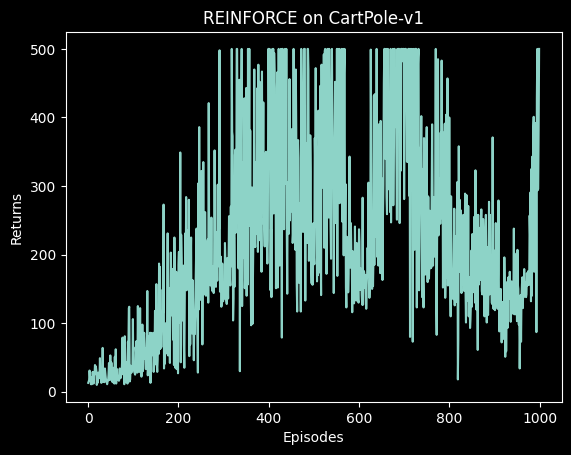

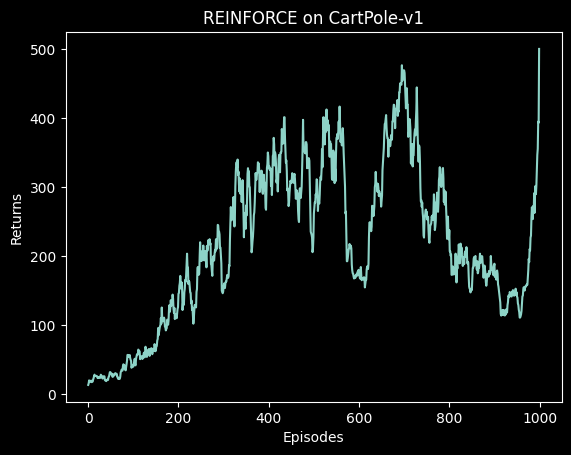

In [5]:
episode_list = list(range(len(return_list)))
plt.plot(episode_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('REINFORCE on CartPole-v1')
plt.show()

def moving_average(a, window_size):
    cumulative_sum = np.cumsum(np.insert(a, 0, 0))
    middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size

    r = np.arange(1, window_size, 2)
    begin = np.cumsum(a[:window_size-1])[::2] / r
    end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
    return np.concatenate((begin, middle, end))

mv_return = moving_average(return_list, 9)
plt.plot(episode_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('REINFORCE on CartPole-v1')
plt.show()
